**Random Walks**  

*Introduction:*  
A random walk is one of the most fundamental concepts in probability and mathematics. At its core, it is a process where someone, or something, moves in a sequence of random steps, with no fixed direction and no memory of where it has been. Every step is independent of the last. The path it traces is completely unpredictable, and yet, when you study a large number of these paths together, surprisingly consistent patterns emerge.  
Random walks show up everywhere and not just in mathematics. In physics, the motion of a particle suspended in a fluid (known as Brownian motion) is a random walk. In finance, stock prices are often modelled as random walks, since each day's movement is largely independent of the previous day's. In biology, the way an animal forages for food follows a random walk. In computer science, Google's PageRank algorithm, which ranks websites by importance, is essentially a random walk over the internet, where a person clicking links randomly tends to land on the most important pages most often.
The reason random walks matter is not just because of where they appear, but because of what they reveal -- that randomness, when studied at scale, is not as chaotic as it seems. There is structure hidden inside it, and that structure is exactly what this simulation is built to uncover.

*Problem Statement:*  
Suppose you are standing at position 0 on a number line. At every step, you flip a coin. If it's heads, you move one step to the right (+1), tails, you move one step to the left (-1). Both outcomes are equally likely, with a probability of 0.5 each. You repeat this for n steps. The question is: After n steps, where do you end up?  

*The Paradox:*  
Now, the intuitive answer most of us would give is that since every step to the right is equally likely as a step to the left, the walker should always end up somewhere close to where they started, which in this case, is near 0. And in a sense, this is true. The expected final position is indeed 0.  
However, this is only half the story.  
While the walker is equally likely to be at +k or -k for any value of k, the typical distance from 0 is not 0 at all. It actually grows with the number of steps. Specifically, after n steps, the typical displacement from the origin turns out to be √n. This means that a walker taking 100 steps typically ends up about 10 units away from where they started. A walker taking 10,000 steps typically ends up about 100 units away.  
So how can the expected position be 0, but the typical distance from 0 keep growing? This is exactly what makes the random walk counterintuitive.  

*The Solution:*  
Let's think about it this way. The walker is equally likely to land at +10 or -10 after 100 steps. These cancel out when averaged over many walks, which is why the expected position is 0. But in either case, the walker is still 10 units away from the origin. The average of the displacements is 0, but the average of the distances is not.  
This is why we measure the Root Mean Square (RMS) displacement instead of the simple average. The RMS displacement after n steps is √n, and this is what the simulation confirms.  
Therefore, a longer walk does not mean the walker stays closer to home. It means the walker drifts further away.  

**What is this simulation about?**  
This Python code simulates a large number of independent random walks and studies where they end up. We fix the number of steps per walk and the number of walks, and observe the outcomes across three visualisations. The trajectory plot shows a few individual walks -- each one a unique jagged path. The histogram shows where all the walkers ended up, which converges to a bell curve centred at 0, a direct consequence of the Central Limit Theorem. Finally, the scaling plot confirms the √n law, which states that as the number of steps increases, the RMS displacement grows as √n, exactly as predicted.


In [21]:
import random
import matplotlib.pyplot as plt
import math
%matplotlib inline
random.seed(42)

**Function that runs for n number of steps, and defines one random walk**

In [10]:
def random_walk(n):                        #defining the function which takes the input n, number of steps per walk
    total = 0                              #keeps a running total of the current position
    position = []                          #stores the position after each step
    
    for i in range(n+1):
        value = [-1,1]
        step = random.choice(value)
        total+=step
        position.append(total)

    return position                        #returning the trajectory list   

**Running the random walks for N number of trials**

In [11]:
n = 1000                           #number of steps per walk
N = 10000                          #number of trials/walks to simulate
trajectory = []                    #list that stores the full trajectories of the first 15 walks
final_position = []                #list that stores the final position of each walk


for i in range(N):
    walk = random_walk(n)          #running the simulation     
    final = walk[-1]                
    final_position.append(final)   #storing the final position of each walk
    if i < 10:
        trajectory.append(walk)    #storing the trajectories only for the first 10 walks
        

**Computing and Printing the summary statistics**

In [12]:
mean = sum(final_position) / N

squares = [i*i for i in final_position]
experimental_rms = math.sqrt(sum(squares) / N)
theoretical_rms = math.sqrt(n)

print(f"Results over {N:,} walks of {n:,} steps wach:")
print("Theoretical Mean of final positions: 0")
print(f"Experimental Mean of final positions: {mean: .2f}")
print(f"Theoretical RMS of displacement (√{n}): {theoretical_rms: .2f}")
print(f"Experimental RMS of displacement: {experimental_rms: .2f}")

Results over 10,000 walks of 1,000 steps wach:
Theoretical Mean of final positions: 0
Experimental Mean of final positions:  0.03
Theoretical RMS of displacement (√1000):  31.62
Experimental RMS of displacement:  31.79


**Visualising the Results: Graphs for Sample Trajectories, Final Positions, RMS Displacement vs Steps (The √n Scaling Plot)**

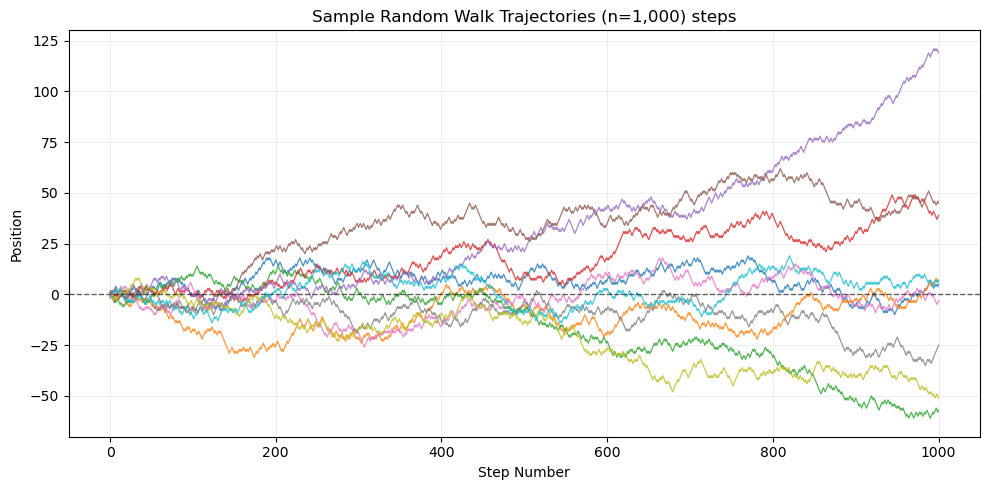

In [14]:
fig, ax = plt.subplots(figsize = (10, 5))
for i in trajectory:
    ax.plot(range(n + 1),
            i,
            alpha = 0.8,
            linewidth = 0.9
           )

ax.axhline(y = 0,
           color = 'black',
           linestyle = '--',
           linewidth = 1,
           alpha = 0.6
          )

ax.set_xlabel('Step Number')
ax.set_ylabel('Position')
ax.set_title(f'Sample Random Walk Trajectories (n={n:,}) steps')
ax.grid(True, alpha = 0.2)

plt.tight_layout()
plt.show()

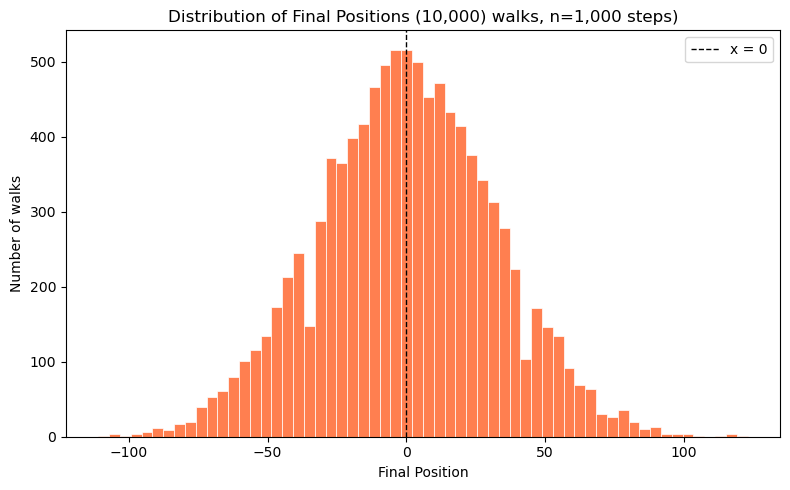

In [18]:
fig, ax = plt.subplots(figsize = (8, 5))

ax.hist(final_position,
        bins = 60,
        color = 'coral',
        edgecolor = 'white',
        linewidth = 0.5
       )

ax.axvline(x = 0,
           color = 'black',
           linestyle = '--',
           linewidth = 1,
           label = 'x = 0'
          )

ax.set_xlabel('Final Position')
ax.set_ylabel('Number of walks')
ax.set_title(f'Distribution of Final Positions ({N:,}) walks, n={n:,} steps)')

ax.legend()

plt.tight_layout()
plt.show()

This is a bell curve (normal distribution) centered at 0. Here, we can see that many independent random steps converge to a normal distribution, irrespective of what the individual step looks like. This, right here, is the Central Limit Theorem in action

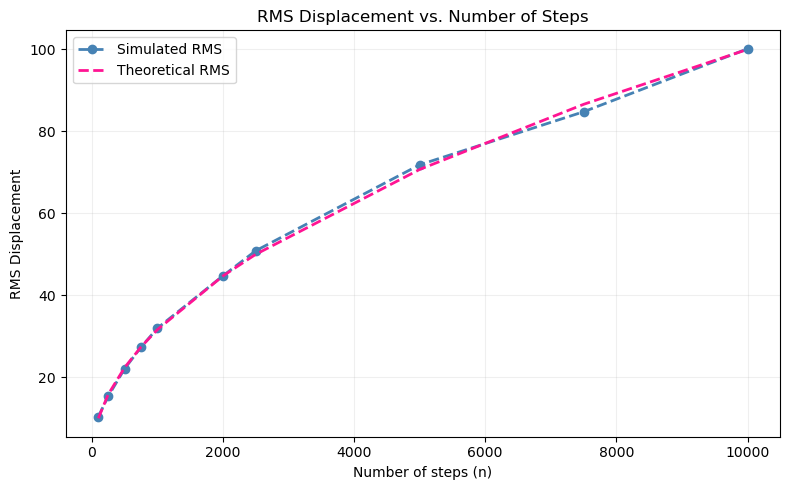

In [20]:
steps = [100, 250, 500, 750, 1000, 2000, 2500, 5000, 7500, 10000]
rms_value = []
trials = 1000

for j in steps:
    finals = []
    for k in range (trials):
        l = random_walk(j)
        finals.append(l[-1])

    rms = math.sqrt(sum(i*i for i in finals) / len(finals))
    rms_value.append(rms)

theoretical_value = [math.sqrt(s) for s in steps]

fig, ax = plt.subplots(figsize = (8,5))

ax.plot(steps,
        rms_value,
        'o--',
        color = 'steelblue',
        label = 'Simulated RMS',
        linewidth = 2
       )

ax.plot(steps,
        theoretical_value,
        '--',
        color = 'deeppink',
        label = 'Theoretical RMS',
        linewidth = 2
       )

ax.set_xlabel('Number of steps (n)')
ax.set_ylabel('RMS Displacement')
ax.set_title('RMS Displacement vs. Number of Steps')
ax.legend()
ax.grid(True, alpha = 0.2)

plt.tight_layout()
plt.show()

This final plot shows the √n Scaling Plot. This is yet again an example of the Law of Large Numbers in action. What this means is that if we conduct the experiment large number of times, the experimental value will approach the theoretical value, which in this case is √n.